# Cephalometric Landmark Training with HRNet (Standalone)

This notebook is fully self-contained and **does not use** any YAML configuration from the `experiments/` folder.

It trains HRNet-W32 on the cephalometric dataset using ImageNet pretrained HRNet weights.

Splits used in this notebook:
- Train: for optimization
- Valid: for model selection
- Test: for final held-out evaluation using the best checkpoint

In [1]:
# Configuration Cell 1: Paths and runtime
from pathlib import Path
import torch

PROJECT_ROOT = Path.cwd()
DATA_ROOT = PROJECT_ROOT / "data"
OUTPUT_DIR = PROJECT_ROOT / "output" / "ceph_hrnet_notebook"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

PRETRAINED_WEIGHTS = PROJECT_ROOT / "models" / "hrnetv2_w32_imagenet_pretrained.pth"
ANNOTATOR = "Senior Orthodontists"
TRAIN_SPLIT = "train"
VAL_SPLIT = "valid"
TEST_SPLIT = "test"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
PIN_MEMORY = torch.cuda.is_available()

print(f"Project root: {PROJECT_ROOT}")
print(f"Device: {DEVICE}")
print(f"Pretrained file exists: {PRETRAINED_WEIGHTS.exists()}")

Project root: /home/nhatnm/code/myprojects/HRNet-Ceph-Landmark-Detection
Device: cuda
Pretrained file exists: True


In [2]:
# Configuration Cell 2: Training and data hyperparameters
SEED = 42

NUM_JOINTS = 29
IMAGE_SIZE = (512, 512)      # (width, height)
HEATMAP_SIZE = (128, 128)    # (width, height)
SIGMA = 2.5

BATCH_SIZE = 4
NUM_WORKERS = 8
EPOCHS = 20
BASE_LR = 2e-4
WEIGHT_DECAY = 1e-4
USE_AMP = True
GRAD_CLIP_NORM = 1.0

ROT_DEG = 8.0
SCALE_RANGE = 0.08
INTENSITY_JITTER = 0.10

RESUME_CHECKPOINT = None
SAVE_EVERY = 1

In [3]:
# Configuration Cell 3: HRNet-W32 architecture (standalone, no experiment YAML)
HRNET_W32_EXTRA = {
    "FINAL_CONV_KERNEL": 1,
    "STAGE2": {
        "NUM_MODULES": 1,
        "NUM_BRANCHES": 2,
        "NUM_BLOCKS": [4, 4],
        "NUM_CHANNELS": [32, 64],
        "BLOCK": "BASIC",
        "FUSE_METHOD": "SUM",
    },
    "STAGE3": {
        "NUM_MODULES": 4,
        "NUM_BRANCHES": 3,
        "NUM_BLOCKS": [4, 4, 4],
        "NUM_CHANNELS": [32, 64, 128],
        "BLOCK": "BASIC",
        "FUSE_METHOD": "SUM",
    },
    "STAGE4": {
        "NUM_MODULES": 3,
        "NUM_BRANCHES": 4,
        "NUM_BLOCKS": [4, 4, 4, 4],
        "NUM_CHANNELS": [32, 64, 128, 256],
        "BLOCK": "BASIC",
        "FUSE_METHOD": "SUM",
    },
}

In [4]:
import copy
import json
import math
import os
import random
import sys
import time
from dataclasses import dataclass

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from lib.models.hrnet import HighResolutionNet


def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_seed(SEED)

/home/nhatnm/code/myprojects/HRNet-Ceph-Landmark-Detection/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
class AttrDict(dict):
    def __getattr__(self, key):
        if key not in self:
            raise AttributeError(key)
        value = self[key]
        if isinstance(value, dict) and not isinstance(value, AttrDict):
            value = AttrDict(value)
            self[key] = value
        return value

    def __setattr__(self, key, value):
        self[key] = value


def build_hrnet_config(num_joints: int) -> AttrDict:
    cfg = AttrDict()
    cfg.MODEL = AttrDict()
    cfg.MODEL.NUM_JOINTS = num_joints
    cfg.MODEL.EXTRA = AttrDict(copy.deepcopy(HRNET_W32_EXTRA))
    cfg.MODEL.PRETRAINED = str(PRETRAINED_WEIGHTS)
    cfg.MODEL.INIT_WEIGHTS = False
    return cfg


def safe_torch_load(path):
    try:
        return torch.load(path, map_location="cpu")
    except TypeError:
        return torch.load(path, map_location="cpu")


def load_hrnet_pretrained(model: nn.Module, checkpoint_path: Path) -> None:
    if not checkpoint_path.exists():
        raise FileNotFoundError(f"Pretrained weights not found: {checkpoint_path}")

    checkpoint = safe_torch_load(str(checkpoint_path))
    state_dict = checkpoint
    if isinstance(checkpoint, dict):
        for key in ["state_dict", "model", "model_state_dict"]:
            if key in checkpoint and isinstance(checkpoint[key], dict):
                state_dict = checkpoint[key]
                break

    clean_state = {}
    for k, v in state_dict.items():
        nk = k.replace("module.", "")
        clean_state[nk] = v

    model_dict = model.state_dict()
    matched = {k: v for k, v in clean_state.items() if k in model_dict and model_dict[k].shape == v.shape}
    missing = len(model_dict) - len(matched)

    model_dict.update(matched)
    model.load_state_dict(model_dict)

    print(f"Loaded pretrained params: {len(matched)} | Missing in pretrained: {missing}")


def draw_gaussian(heatmap: np.ndarray, center: np.ndarray, sigma: float) -> np.ndarray:
    tmp_size = int(sigma * 3)
    mu_x = int(center[0] + 0.5)
    mu_y = int(center[1] + 0.5)

    h, w = heatmap.shape
    ul = [mu_x - tmp_size, mu_y - tmp_size]
    br = [mu_x + tmp_size + 1, mu_y + tmp_size + 1]

    if ul[0] >= w or ul[1] >= h or br[0] < 0 or br[1] < 0:
        return heatmap

    size = 2 * tmp_size + 1
    x = np.arange(0, size, 1, np.float32)
    y = x[:, None]
    x0 = y0 = size // 2
    g = np.exp(-((x - x0) ** 2 + (y - y0) ** 2) / (2 * sigma ** 2))

    g_x = max(0, -ul[0]), min(br[0], w) - ul[0]
    g_y = max(0, -ul[1]), min(br[1], h) - ul[1]
    img_x = max(0, ul[0]), min(br[0], w)
    img_y = max(0, ul[1]), min(br[1], h)

    heatmap[img_y[0]:img_y[1], img_x[0]:img_x[1]] = np.maximum(
        heatmap[img_y[0]:img_y[1], img_x[0]:img_x[1]],
        g[g_y[0]:g_y[1], g_x[0]:g_x[1]],
    )
    return heatmap


class CephLandmarkDataset(Dataset):
    def __init__(
        self,
        data_root: Path,
        split: str,
        annotator: str,
        image_size=(512, 512),
        heatmap_size=(128, 128),
        sigma=2.5,
        num_joints=29,
        is_train=True,
        rot_deg=8.0,
        scale_range=0.08,
        intensity_jitter=0.10,
    ):
        self.data_root = Path(data_root)
        self.split = split
        self.annotator = annotator
        self.image_size = image_size
        self.heatmap_size = heatmap_size
        self.sigma = sigma
        self.num_joints = num_joints
        self.is_train = is_train
        self.rot_deg = rot_deg
        self.scale_range = scale_range
        self.intensity_jitter = intensity_jitter

        self.mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
        self.std = np.array([0.229, 0.224, 0.225], dtype=np.float32)

        self.image_dir = self.data_root / split / "Cephalograms"
        self.ann_dir = self.data_root / split / "Annotations" / "Cephalometric Landmarks" / annotator

        if not self.image_dir.exists():
            raise FileNotFoundError(f"Image directory does not exist: {self.image_dir}")
        if not self.ann_dir.exists():
            raise FileNotFoundError(f"Annotation directory does not exist: {self.ann_dir}")

        valid_ext = {".png", ".jpg", ".jpeg", ".bmp"}
        image_paths = sorted([p for p in self.image_dir.iterdir() if p.suffix.lower() in valid_ext])
        self.samples = []
        for img_path in image_paths:
            ann_path = self.ann_dir / f"{img_path.stem}.json"
            if ann_path.exists():
                self.samples.append((img_path, ann_path))

        if not self.samples:
            raise RuntimeError(f"No samples found in split={split}")

        with open(self.samples[0][1], "r", encoding="utf-8") as f:
            first_ann = json.load(f)
        self.landmark_order = [lm["symbol"] for lm in first_ann["landmarks"]]
        if len(self.landmark_order) != self.num_joints:
            raise ValueError(
                f"Expected {self.num_joints} joints but found {len(self.landmark_order)} in annotations"
            )

        self.pixel_size_map = {}
        mapping_csv = self.data_root / "cephalogram_machine_mappings.csv"
        if mapping_csv.exists():
            df = pd.read_csv(mapping_csv)
            if "cephalogram_id" in df.columns and "pixel_size" in df.columns:
                for _, row in df.iterrows():
                    self.pixel_size_map[str(row["cephalogram_id"])] = float(row["pixel_size"])

    def __len__(self):
        return len(self.samples)

    def _load_points(self, ann_path: Path) -> np.ndarray:
        with open(ann_path, "r", encoding="utf-8") as f:
            ann = json.load(f)

        symbol_to_xy = {lm["symbol"]: (lm["value"]["x"], lm["value"]["y"]) for lm in ann["landmarks"]}
        pts = []
        for symbol in self.landmark_order:
            if symbol not in symbol_to_xy:
                raise KeyError(f"Missing symbol {symbol} in {ann_path}")
            pts.append(symbol_to_xy[symbol])
        return np.array(pts, dtype=np.float32)

    def _augment(self, img: np.ndarray, pts: np.ndarray):
        if not self.is_train:
            return img, pts

        h, w = img.shape[:2]
        center = (w / 2.0, h / 2.0)

        angle = np.random.uniform(-self.rot_deg, self.rot_deg)
        scale = 1.0 + np.random.uniform(-self.scale_range, self.scale_range)

        M = cv2.getRotationMatrix2D(center, angle, scale)
        img = cv2.warpAffine(
            img,
            M,
            (w, h),
            flags=cv2.INTER_LINEAR,
            borderMode=cv2.BORDER_CONSTANT,
            borderValue=(0, 0, 0),
        )

        pts_h = np.concatenate([pts, np.ones((pts.shape[0], 1), dtype=np.float32)], axis=1)
        pts = (pts_h @ M.T).astype(np.float32)

        if self.intensity_jitter > 0:
            alpha = 1.0 + np.random.uniform(-self.intensity_jitter, self.intensity_jitter)
            beta = np.random.uniform(-20.0, 20.0)
            img = np.clip(alpha * img.astype(np.float32) + beta, 0, 255).astype(np.uint8)

        return img, pts

    def __getitem__(self, index):
        img_path, ann_path = self.samples[index]

        bgr = cv2.imread(str(img_path), cv2.IMREAD_COLOR | cv2.IMREAD_IGNORE_ORIENTATION)
        if bgr is None:
            raise ValueError(f"Failed to read image: {img_path}")
        img = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

        pts = self._load_points(ann_path)
        original_pts = pts.copy()

        img, pts = self._augment(img, pts)

        orig_h, orig_w = img.shape[:2]
        out_w, out_h = self.image_size

        img_resized = cv2.resize(img, (out_w, out_h), interpolation=cv2.INTER_LINEAR)

        sx = out_w / float(orig_w)
        sy = out_h / float(orig_h)

        pts_resized = pts.copy()
        pts_resized[:, 0] *= sx
        pts_resized[:, 1] *= sy

        hm_w, hm_h = self.heatmap_size
        target = np.zeros((self.num_joints, hm_h, hm_w), dtype=np.float32)
        target_weight = np.ones((self.num_joints, 1), dtype=np.float32)

        hm_x_ratio = hm_w / float(out_w)
        hm_y_ratio = hm_h / float(out_h)

        for j in range(self.num_joints):
            x, y = pts_resized[j]
            hx = x * hm_x_ratio
            hy = y * hm_y_ratio
            if hx < 0 or hy < 0 or hx >= hm_w or hy >= hm_h:
                target_weight[j, 0] = 0.0
                continue
            target[j] = draw_gaussian(target[j], np.array([hx, hy], dtype=np.float32), self.sigma)

        img_norm = img_resized.astype(np.float32) / 255.0
        img_norm = (img_norm - self.mean) / self.std
        img_norm = img_norm.transpose(2, 0, 1)

        sample_id = img_path.stem
        pixel_size = self.pixel_size_map.get(sample_id, np.nan)

        meta = {
            "image_id": sample_id,
            "coords_original": torch.tensor(original_pts, dtype=torch.float32),
            "resize_factors": torch.tensor([sx, sy], dtype=torch.float32),
            "pixel_size_mm": torch.tensor(pixel_size, dtype=torch.float32),
        }

        return (
            torch.tensor(img_norm, dtype=torch.float32),
            torch.tensor(target, dtype=torch.float32),
            torch.tensor(target_weight, dtype=torch.float32),
            meta,
        )


def decode_heatmaps_argmax(heatmaps: torch.Tensor) -> torch.Tensor:
    b, j, h, w = heatmaps.shape
    flat = heatmaps.reshape(b, j, -1)
    idx = flat.argmax(dim=-1)
    x = (idx % w).float()
    y = (idx // w).float()
    return torch.stack([x, y], dim=-1)


print("Dataset and utility functions are ready.")

Dataset and utility functions are ready.


In [6]:
train_ds = CephLandmarkDataset(
    data_root=DATA_ROOT,
    split=TRAIN_SPLIT,
    annotator=ANNOTATOR,
    image_size=IMAGE_SIZE,
    heatmap_size=HEATMAP_SIZE,
    sigma=SIGMA,
    num_joints=NUM_JOINTS,
    is_train=True,
    rot_deg=ROT_DEG,
    scale_range=SCALE_RANGE,
    intensity_jitter=INTENSITY_JITTER,
)

val_ds = CephLandmarkDataset(
    data_root=DATA_ROOT,
    split=VAL_SPLIT,
    annotator=ANNOTATOR,
    image_size=IMAGE_SIZE,
    heatmap_size=HEATMAP_SIZE,
    sigma=SIGMA,
    num_joints=NUM_JOINTS,
    is_train=False,
)

test_ds = CephLandmarkDataset(
    data_root=DATA_ROOT,
    split=TEST_SPLIT,
    annotator=ANNOTATOR,
    image_size=IMAGE_SIZE,
    heatmap_size=HEATMAP_SIZE,
    sigma=SIGMA,
    num_joints=NUM_JOINTS,
    is_train=False,
)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    drop_last=True,
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    drop_last=False,
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    drop_last=False,
)

print(f"Train samples: {len(train_ds)}")
print(f"Valid samples: {len(val_ds)}")
print(f"Test samples: {len(test_ds)}")

batch = next(iter(train_loader))
images, targets, target_weight, meta = batch
print("Image batch:", images.shape)
print("Target batch:", targets.shape)
print("Target weight batch:", target_weight.shape)

Train samples: 700
Valid samples: 150
Test samples: 150
Image batch: torch.Size([4, 3, 512, 512])
Target batch: torch.Size([4, 29, 128, 128])
Target weight batch: torch.Size([4, 29, 1])


In [7]:
cfg = build_hrnet_config(num_joints=NUM_JOINTS)
model = HighResolutionNet(cfg).to(DEVICE)
load_hrnet_pretrained(model, PRETRAINED_WEIGHTS)

criterion = nn.MSELoss(reduction="none")
optimizer = torch.optim.AdamW(model.parameters(), lr=BASE_LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)
scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP and DEVICE == "cuda")

start_epoch = 1
best_val_mre_mm = float("inf")
history = {"epoch": [], "train_loss": [], "val_loss": [], "val_mre_px": [], "val_mre_mm": []}

if RESUME_CHECKPOINT is not None:
    ckpt = torch.load(RESUME_CHECKPOINT, map_location="cpu")
    model.load_state_dict(ckpt["model_state_dict"])
    optimizer.load_state_dict(ckpt["optimizer_state_dict"])
    scheduler.load_state_dict(ckpt["scheduler_state_dict"])
    if "scaler_state_dict" in ckpt and ckpt["scaler_state_dict"] is not None:
        scaler.load_state_dict(ckpt["scaler_state_dict"])
    start_epoch = ckpt["epoch"] + 1
    best_val_mre_mm = ckpt.get("best_val_mre_mm", best_val_mre_mm)
    print(f"Resumed from epoch {ckpt['epoch']}")

print("Model initialized.")

Loaded pretrained params: 1830 | Missing in pretrained: 9
Model initialized.


/tmp/ipykernel_183702/653001631.py:8: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP and DEVICE == "cuda")


In [ ]:
def weighted_heatmap_mse(pred: torch.Tensor, target: torch.Tensor, target_weight: torch.Tensor) -> torch.Tensor:
    # pred/target: [B, J, H, W], target_weight: [B, J, 1]
    loss = criterion(pred, target).mean(dim=(2, 3))
    loss = loss * target_weight.squeeze(-1)
    return loss.sum() / target_weight.squeeze(-1).sum().clamp_min(1.0)


def train_one_epoch(model, loader, optimizer, scaler, device):
    model.train()
    running_loss = 0.0

    pbar = tqdm(loader, desc="Train", leave=False)
    for images, targets, target_weight, _ in pbar:
        images = images.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)
        target_weight = target_weight.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=USE_AMP and device == "cuda"):
            outputs = model(images)
            loss = weighted_heatmap_mse(outputs, targets, target_weight)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()
        pbar.set_postfix(loss=f"{loss.item():.4f}")

    return running_loss / max(len(loader), 1)


@torch.no_grad()
def validate(model, loader, device, split_name="Valid"):
    model.eval()
    running_loss = 0.0
    all_px_errors = []
    all_mm_errors = []

    hm_w, hm_h = HEATMAP_SIZE
    img_w, img_h = IMAGE_SIZE

    for images, targets, target_weight, meta in tqdm(loader, desc=split_name, leave=False):
        images = images.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)
        target_weight = target_weight.to(device, non_blocking=True)

        outputs = model(images)
        loss = weighted_heatmap_mse(outputs, targets, target_weight)
        running_loss += loss.item()

        pred_hm = decode_heatmaps_argmax(outputs)
        pred_img = pred_hm.clone()
        pred_img[..., 0] *= img_w / float(hm_w)
        pred_img[..., 1] *= img_h / float(hm_h)

        resize_factors = meta["resize_factors"].to(device)
        gt_original = meta["coords_original"].to(device)

        pred_original = pred_img.clone()
        pred_original[..., 0] /= resize_factors[:, None, 0]
        pred_original[..., 1] /= resize_factors[:, None, 1]

        dists_px = torch.linalg.norm(pred_original - gt_original, dim=-1)
        all_px_errors.append(dists_px.cpu())

        pixel_size_mm = meta["pixel_size_mm"].to(device)
        valid_mm_mask = torch.isfinite(pixel_size_mm)
        if valid_mm_mask.any():
            dists_mm = dists_px[valid_mm_mask] * pixel_size_mm[valid_mm_mask][:, None]
            all_mm_errors.append(dists_mm.cpu())

    eval_loss = running_loss / max(len(loader), 1)
    mre_px = torch.cat(all_px_errors, dim=0).mean().item() if all_px_errors else float("nan")
    mre_mm = torch.cat(all_mm_errors, dim=0).mean().item() if all_mm_errors else float("nan")

    return eval_loss, mre_px, mre_mm


for epoch in range(start_epoch, EPOCHS + 1):
    t0 = time.time()

    train_loss = train_one_epoch(model, train_loader, optimizer, scaler, DEVICE)
    val_loss, val_mre_px, val_mre_mm = validate(model, val_loader, DEVICE, split_name="Valid")
    scheduler.step()

    history["epoch"].append(epoch)
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_mre_px"].append(val_mre_px)
    history["val_mre_mm"].append(val_mre_mm)

    elapsed = time.time() - t0
    print(
        f"Epoch {epoch:03d}/{EPOCHS:03d} | "
        f"train_loss={train_loss:.5f} | val_loss={val_loss:.5f} | "
        f"val_mre_px={val_mre_px:.3f} | val_mre_mm={val_mre_mm:.3f} | "
        f"time={elapsed/60:.1f}m"
    )

    checkpoint = {
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "scaler_state_dict": scaler.state_dict() if scaler is not None else None,
        "best_val_mre_mm": best_val_mre_mm,
        "config": {
            "image_size": IMAGE_SIZE,
            "heatmap_size": HEATMAP_SIZE,
            "sigma": SIGMA,
            "num_joints": NUM_JOINTS,
            "annotator": ANNOTATOR,
        },
        "history": history,
    }

    if epoch % SAVE_EVERY == 0:
        torch.save(checkpoint, OUTPUT_DIR / "last_checkpoint.pth")

    if val_mre_mm < best_val_mre_mm:
        best_val_mre_mm = val_mre_mm
        checkpoint["best_val_mre_mm"] = best_val_mre_mm
        torch.save(checkpoint, OUTPUT_DIR / "best_model.pth")
        print(f"  New best model saved (val_mre_mm={best_val_mre_mm:.3f})")

pd.DataFrame(history).to_csv(OUTPUT_DIR / "training_history.csv", index=False)

best_model_path = OUTPUT_DIR / "best_model.pth"
if best_model_path.exists():
    best_ckpt = torch.load(best_model_path, map_location="cpu")
    model.load_state_dict(best_ckpt["model_state_dict"])
    print("Loaded best checkpoint for final test evaluation.")

test_loss, test_mre_px, test_mre_mm = validate(model, test_loader, DEVICE, split_name="Test")
print(
    f"Test results | loss={test_loss:.5f} | "
    f"mre_px={test_mre_px:.3f} | mre_mm={test_mre_mm:.3f}"
)

test_metrics_df = pd.DataFrame([
    {
        "split": TEST_SPLIT,
        "loss": test_loss,
        "mre_px": test_mre_px,
        "mre_mm": test_mre_mm,
    }
])
test_metrics_df.to_csv(OUTPUT_DIR / "test_metrics.csv", index=False)

print(f"Training complete. Artifacts saved to: {OUTPUT_DIR}")

Train:   0%|          | 0/175 [00:00<?, ?it/s]/tmp/ipykernel_183702/3081496515.py:20: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP and device == "cuda"):


Epoch 001/020 | train_loss=0.00755 | val_loss=0.00275 | val_mre_px=111.703 | val_mre_mm=12.013 | time=0.7m
  New best model saved (val_mre_mm=12.013)


Epoch 002/020 | train_loss=0.00064 | val_loss=0.00059 | val_mre_px=19.779 | val_mre_mm=2.281 | time=0.8m


,epoch,train_loss,val_loss,val_mre_px,val_mre_mm
15,16,0.000130,0.000168,13.954197,1.602396
16,17,0.000128,0.000164,13.871939,1.593560
17,18,0.000125,0.000162,13.744625,1.582709
18,19,0.000123,0.000160,13.543937,1.559813
19,20,0.000123,0.000160,13.558856,1.560813


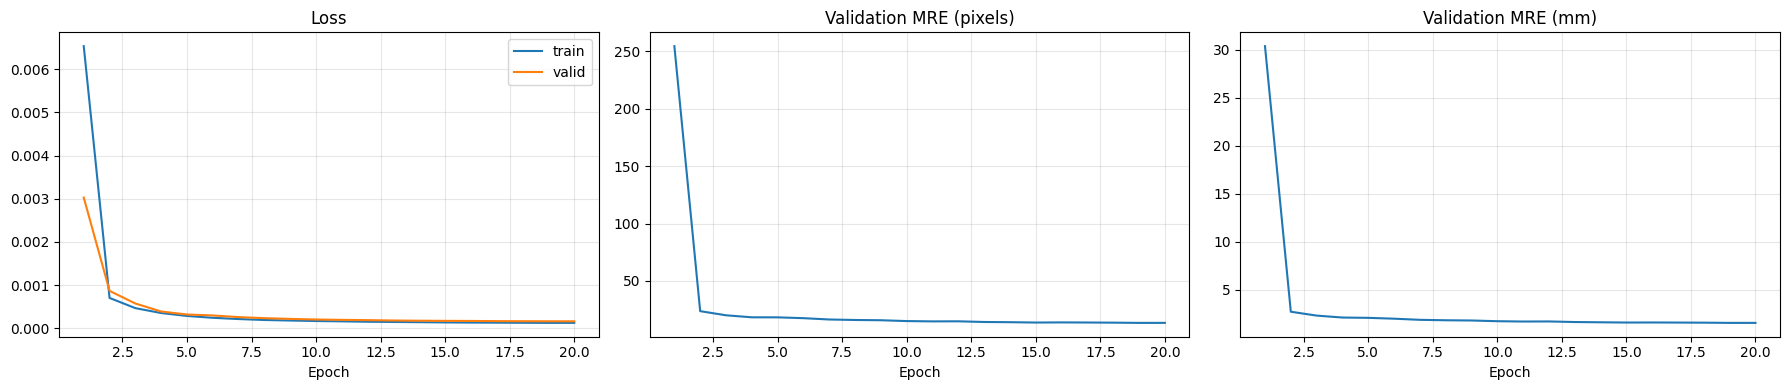

In [ ]:
hist_df = pd.DataFrame(history)
display(hist_df.tail())

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
axes[0].plot(hist_df["epoch"], hist_df["train_loss"], label="train")
axes[0].plot(hist_df["epoch"], hist_df["val_loss"], label="valid")
axes[0].set_title("Loss")
axes[0].legend()

axes[1].plot(hist_df["epoch"], hist_df["val_mre_px"])
axes[1].set_title("Validation MRE (pixels)")

axes[2].plot(hist_df["epoch"], hist_df["val_mre_mm"])
axes[2].set_title("Validation MRE (mm)")

for ax in axes:
    ax.set_xlabel("Epoch")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

test_metrics_path = OUTPUT_DIR / "test_metrics.csv"
if test_metrics_path.exists():
    test_df = pd.read_csv(test_metrics_path)
    print("Final held-out test metrics:")
    display(test_df)
else:
    print("No test metrics found yet. Run Cell 9 first to generate test_metrics.csv.")

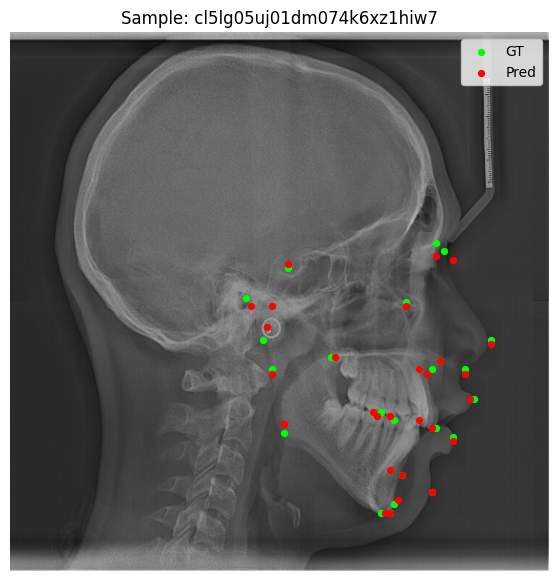

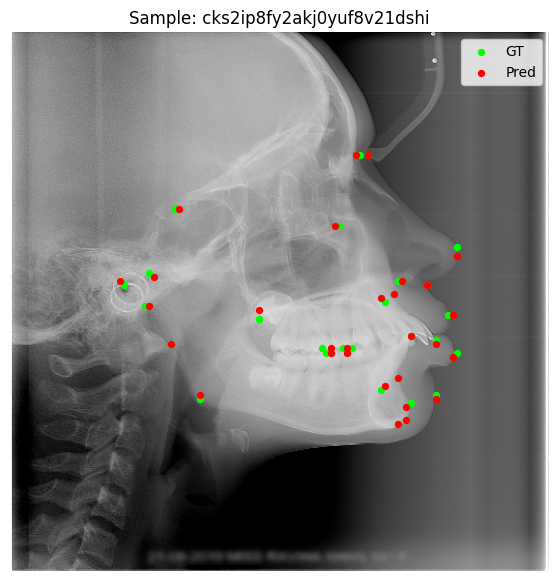

In [ ]:
@torch.no_grad()
def visualize_predictions(model, dataset, device, n_samples=2):
    model.eval()
    idxs = np.random.choice(len(dataset), size=min(n_samples, len(dataset)), replace=False)

    for idx in idxs:
        image, target, _, meta = dataset[idx]
        inp = image.unsqueeze(0).to(device)

        pred_hm = model(inp)
        pred_xy = decode_heatmaps_argmax(pred_hm).squeeze(0).cpu().numpy()

        hm_w, hm_h = HEATMAP_SIZE
        img_w, img_h = IMAGE_SIZE
        pred_xy[:, 0] *= img_w / float(hm_w)
        pred_xy[:, 1] *= img_h / float(hm_h)

        vis = image.permute(1, 2, 0).cpu().numpy()
        vis = (vis * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406]))
        vis = np.clip(vis, 0, 1)

        gt = target.numpy()
        gt_idx = np.argmax(gt.reshape(NUM_JOINTS, -1), axis=1)
        gt_xy = np.stack([gt_idx % hm_w, gt_idx // hm_w], axis=1).astype(np.float32)
        gt_xy[:, 0] *= img_w / float(hm_w)
        gt_xy[:, 1] *= img_h / float(hm_h)

        plt.figure(figsize=(7, 7))
        plt.imshow(vis)
        plt.scatter(gt_xy[:, 0], gt_xy[:, 1], s=18, c="lime", label="GT")
        plt.scatter(pred_xy[:, 0], pred_xy[:, 1], s=18, c="red", label="Pred")
        plt.title(f"Sample: {meta['image_id']}")
        plt.legend()
        plt.axis("off")
        plt.show()


visualize_predictions(model, val_ds, DEVICE, n_samples=2)